---

## **DIPLOME UNIVERSITAIRE SDA**

## **ML Ops**

---

---
## **Prédiction de défaut de paiement (Loan Default)**

## **NB2_FEATURES : Preprocessing et Feature Engineering**
---

### **Contexte**

Ce notebook fait suite au NB1_EDA. Il prépare les données pour la modélisation :
suppression des colonnes inutiles, création de nouvelles features (ratios), split train/test, normalisation.

### **Données**

- **Dataset** : `Loan_Data.csv` - 10 000 clients bancaires (synthétique)
- **Variable cible** : `default` (binaire : 0 = pas de défaut, 1 = défaut)
- **Modèles imposés** : Decision Tree, Régression Logistique, Random Forest

---

---

### Plan du notebook

| Section | Contenu |
|---------|--------|
| 1. Configuration | Imports, chemins relatifs, seed, versions, constantes |
| 2. Chargement et quality gates | CSV, assertions, vérification structurelle |
| 3. Feature engineering | Ratios dette/revenu et dette/pret, visualisation |
| 4. Preprocessing | Suppression customer_id, split train/test, StandardScaler |
| 5. Sauvegarde | Export des datasets préprocessés |
| 6. Conclusion | Constats, limites, choix pour le NB3 |

---

---

### Objectif du notebook

Ce notebook est un **livrable de pipeline (preprocessing et feature engineering)**. Il couvre la préparation des données brutes en données prêtes pour la modélisation.

Il est conçu pour être :
- **reproductible** (chemins relatifs, seed fixe),
- **idempotent** (relançable sans effet de bord),
- **traçable** (quality gates go/no-go explicites, assertions),
- **orienté décisions** : chaque transformation est justifiée par un constat du NB1_EDA.

---

In [14]:
# 1.1. Imports
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ajouter ici les imports spécifiques au notebook
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler

print(">> 1.1. Imports : OK")

>> 1.1. Imports : OK


In [15]:
# 1.2. Chemins relatifs (pipeline)
BASE = Path.cwd()
if not (BASE / "data").exists():
    BASE = BASE.parent
DATA_DIR = BASE / "data"
OUTPUT_DIR = BASE / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR = BASE / "model"
MODEL_DIR.mkdir(exist_ok=True)

CSV_PATH = DATA_DIR / "Loan_Data.csv"
assert CSV_PATH.exists(), f"Fichier introuvable : {CSV_PATH}"

# Convention de nommage des figures :
# OUTPUT_DIR / "NBx_nom_figure.png" (ex: NB1_eda_boxplots.png, NB2_feature_importance.png)
#
# Convention de sauvegarde des graphiques :
# plt.tight_layout()                                        # ajuster les marges
# plt.savefig(OUTPUT_DIR / "NBx_nom_figure.png", dpi=150)   # sauvegarder (dpi=150 standard projet)
# plt.show()                                                # afficher dans le notebook

print(f"Base    : {BASE}")
print(f"Fichier : {CSV_PATH}")
print(">> 1.2. Chemins : OK")

Base    : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego
Fichier : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\data\Loan_Data.csv
>> 1.2. Chemins : OK


In [16]:
# 1.3. Versions / seed
print("python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("seaborn :", sns.__version__)

SEED = 42
np.random.seed(SEED)

# Toujours utiliser random_state=SEED dans sklearn
# Exemple : train_test_split(..., random_state=SEED)
# Exemple : DecisionTreeClassifier(random_state=SEED)

print(f"SEED    : {SEED}")
print(">> 1.3. Versions / seed : OK")

python  : 3.12.10
pandas  : 2.3.3
numpy   : 2.4.3
seaborn : 0.13.2
SEED    : 42
>> 1.3. Versions / seed : OK


In [17]:
# 1.4. Constantes du projet (héritées du NB1_EDA — ne pas modifier)

CIBLE = "default"
COLONNE_A_SUPPRIMER = ["customer_id"]
FEATURES = [
    "credit_lines_outstanding",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "income",
    "years_employed",
    "fico_score",
]
MODELES_IMPOSES = ["Decision Tree", "Régression Logistique", "Random Forest"]
TEST_SIZE = 0.2
STRATIFY = True

# Stratégie d'évaluation (métriques)
METRIC_PRIMAIRE = "f1"
METRICS_SECONDAIRES = ["recall", "precision", "roc_auc", "average_precision"]

print(">> 1.4. Constantes projet : OK")

>> 1.4. Constantes projet : OK


In [18]:
# 2.1. Chargement des données
df = pd.read_csv(CSV_PATH)
assert len(df) == 10_000, f"Attendu 10 000 lignes, obtenu {len(df)}"
print(f"Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dataset chargé : 10000 lignes, 8 colonnes


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [19]:
# 2.1b. Quality gates (chaque check définit explicitement sa condition de succès)
checks = {
    "nb_lignes": (len(df), len(df) == 10_000),
    "nb_colonnes": (len(df.columns), len(df.columns) == 8),
    "doublons": (df.duplicated().sum(), df.duplicated().sum() == 0),
    "valeurs_manquantes_total": (df.isnull().sum().sum(), df.isnull().sum().sum() == 0),
    "customer_id_unique": (df["customer_id"].nunique(), df["customer_id"].nunique() == len(df)),
}

all_ok = True
for k, (valeur, condition) in checks.items():
    status = "[OK]" if condition else "[KO]"
    if not condition:
        all_ok = False
    print(f"  {status} {k}: {valeur}")

assert all_ok, "Quality gates KO — vérifier les données avant de continuer"
print(">> 2.1b. Quality gates : OK")

  [OK] nb_lignes: 10000
  [OK] nb_colonnes: 8
  [OK] doublons: 0
  [OK] valeurs_manquantes_total: 0
  [OK] customer_id_unique: 10000
>> 2.1b. Quality gates : OK


---

### 3. Feature Engineering

Les ratios ci-dessous ont été identifiés dans le NB1_EDA comme potentiellement discriminants.

---

In [20]:
# 3.1. Création des ratios (sur df complet, avant le split)
# Ratio dette/revenu : identifié dans le NB1_EDA comme plus discriminant que income seul
df["ratio_dette_revenu"] = df["total_debt_outstanding"] / df["income"].replace(0, np.nan)

# Ratio dette/pret : pour mesurer la part de la dette par rapport au pret
df["ratio_dette_pret"] = df["total_debt_outstanding"] / df["loan_amt_outstanding"].replace(0, np.nan)

# Vérification des NaN générés par la division
print("NaN après création des ratios :")
print(df[["ratio_dette_revenu", "ratio_dette_pret"]].isnull().sum())
print()

# Statistiques des nouvelles features par classe
for col in ["ratio_dette_revenu", "ratio_dette_pret"]:
    print(f"--- {col} par classe ---")
    print(df.groupby("default")[col].describe().round(3))
    print()

print(">> 3.1. Ratios créés : OK")

NaN après création des ratios :
ratio_dette_revenu    0
ratio_dette_pret      0
dtype: int64

--- ratio_dette_revenu par classe ---
          count   mean    std    min    25%    50%    75%    max
default                                                         
0        8149.0  0.090  0.045  0.010  0.062  0.087  0.114  0.238
1        1851.0  0.272  0.037  0.162  0.249  0.274  0.297  0.405

--- ratio_dette_pret par classe ---
          count   mean    std    min    25%    50%    75%     max
default                                                          
0        8149.0  1.601  0.874  0.098  1.025  1.488  2.063  10.860
1        1851.0  4.445  1.041  2.118  3.746  4.324  4.985  12.738

>> 3.1. Ratios créés : OK


In [21]:
# 3.1b. Diagnostic NaN et infinis après création des ratios
nan_count = df[["ratio_dette_revenu", "ratio_dette_pret"]].isnull().sum()
inf_count = np.isinf(df[["ratio_dette_revenu", "ratio_dette_pret"]]).sum()

print("=== Diagnostic post-feature engineering ===")
print(f"NaN  ratio_dette_revenu : {nan_count['ratio_dette_revenu']}")
print(f"NaN  ratio_dette_pret   : {nan_count['ratio_dette_pret']}")
print(f"Inf  ratio_dette_revenu : {inf_count['ratio_dette_revenu']}")
print(f"Inf  ratio_dette_pret   : {inf_count['ratio_dette_pret']}")

# Traitement : remplacer les infinis par NaN, puis imputer par la médiane
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in ["ratio_dette_revenu", "ratio_dette_pret"]:
    mediane = df[col].median()
    nb_impute = df[col].isnull().sum()
    if nb_impute > 0:
        df[col].fillna(mediane, inplace=True)
        print(f"  {col} : {nb_impute} valeurs imputées par la médiane ({mediane:.4f})")

assert df[["ratio_dette_revenu", "ratio_dette_pret"]].isnull().sum().sum() == 0, "NaN restants après imputation"
assert np.isinf(df[["ratio_dette_revenu", "ratio_dette_pret"]]).sum().sum() == 0, "Infinis restants après imputation"
print(">> 3.1b. Diagnostic NaN/Inf : OK")

=== Diagnostic post-feature engineering ===
NaN  ratio_dette_revenu : 0
NaN  ratio_dette_pret   : 0
Inf  ratio_dette_revenu : 0
Inf  ratio_dette_pret   : 0
>> 3.1b. Diagnostic NaN/Inf : OK


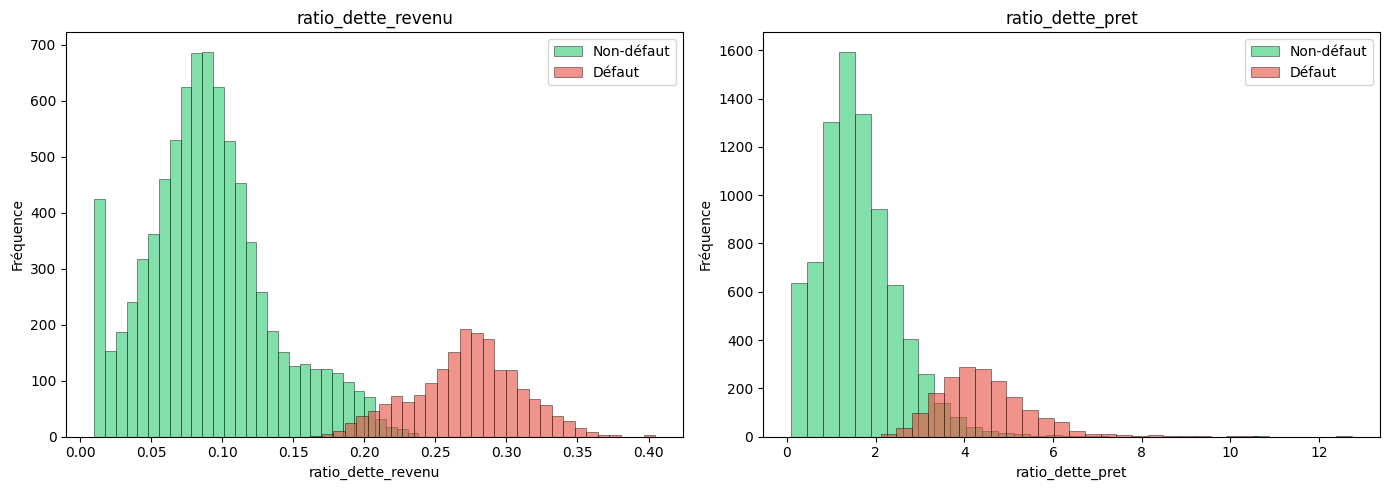

>> 3.2. Visualisation ratios : OK


In [22]:
# 3.2. Visualisation des ratios par classe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["ratio_dette_revenu", "ratio_dette_pret"]):
    for label, color, name in [(0, "#2ecc71", "Non-défaut"), (1, "#e74c3c", "Défaut")]:
        subset = df[df["default"] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=name, edgecolor="black", linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Fréquence")
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB2_ratios_par_classe.png", dpi=150)
plt.show()

print(">> 3.2. Visualisation ratios : OK")

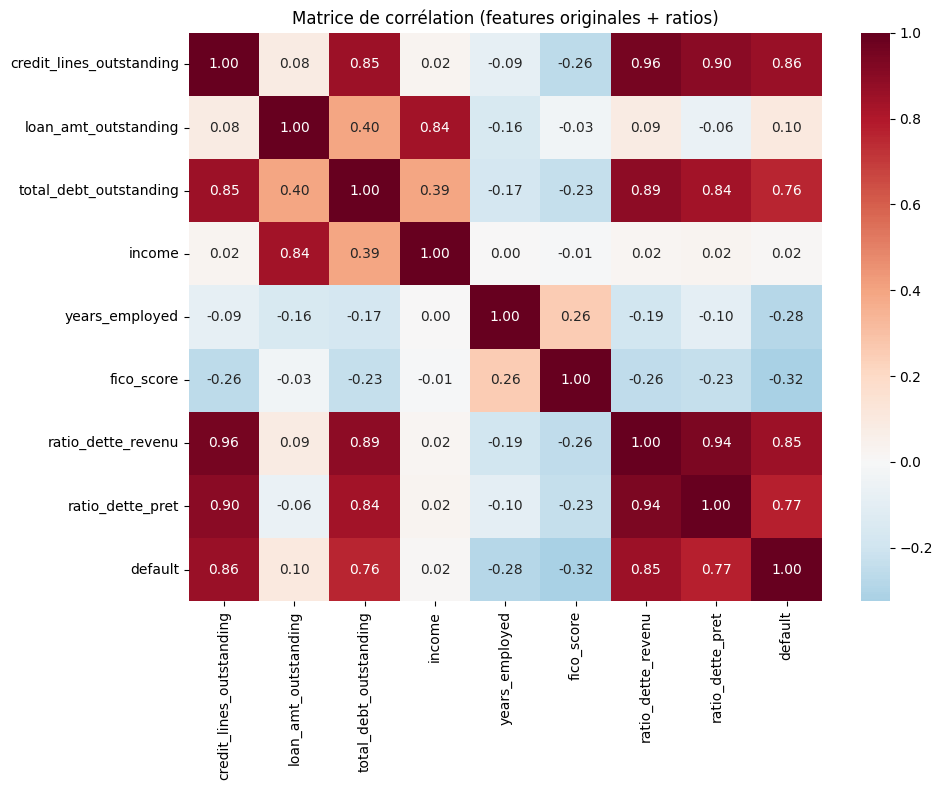

--- Corrélations avec default (triées) ---
credit_lines_outstanding    0.863
ratio_dette_revenu          0.852
ratio_dette_pret            0.773
total_debt_outstanding      0.759
loan_amt_outstanding        0.099
income                      0.016
years_employed             -0.285
fico_score                 -0.325
Name: default, dtype: float64
>> 3.3. Corrélation ratios : OK


In [23]:
# 3.3. Matrice de corrélation avec les nouvelles features
features_corr = FEATURES + ["ratio_dette_revenu", "ratio_dette_pret", "default"]
corr = df[features_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Matrice de corrélation (features originales + ratios)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB2_correlation_avec_ratios.png", dpi=150)
plt.show()

# Corrélations avec la cible
print("--- Corrélations avec default (triées) ---")
print(corr["default"].drop("default").sort_values(ascending=False).round(3))
print(">> 3.3. Corrélation ratios : OK")

In [24]:
# 3.4. Audit d'intégrité du dataset avant preprocessing
FEATURES_AVEC_RATIOS = FEATURES + ["ratio_dette_revenu", "ratio_dette_pret"]
X_audit = df[FEATURES_AVEC_RATIOS]

audit = {
    "shape": (X_audit.shape, True),
    "doublons": (X_audit.duplicated().sum(), X_audit.duplicated().sum() >= 0),
    "infinis": (np.isinf(X_audit).sum().sum(), np.isinf(X_audit).sum().sum() == 0),
    "NaN_total": (X_audit.isnull().sum().sum(), X_audit.isnull().sum().sum() == 0),
    "features_mortes_std0": (
        (X_audit.std() == 0).sum(),
        (X_audit.std() == 0).sum() == 0
    ),
}

print("=== Audit d'intégrité avant preprocessing ===")
all_ok = True
for k, (valeur, condition) in audit.items():
    status = "[OK]" if condition else "[KO]"
    if not condition:
        all_ok = False
    print(f"  {status} {k}: {valeur}")

assert all_ok, "Audit KO — corriger avant de continuer"
print(">> 3.4. Audit intégrité : OK")

=== Audit d'intégrité avant preprocessing ===
  [OK] shape: (10000, 8)
  [OK] doublons: 0
  [OK] infinis: 0
  [OK] NaN_total: 0
  [OK] features_mortes_std0: 0
>> 3.4. Audit intégrité : OK


In [25]:
# 4.1. Preprocessing : suppression, split, normalisation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Suppression de la colonne non informative
df = df.drop(columns=COLONNE_A_SUPPRIMER)

# Features finales (originales + ratios)
FEATURES_FINAL = FEATURES + ["ratio_dette_revenu", "ratio_dette_pret"]

# Séparation features / cible
X = df[FEATURES_FINAL]
y = df[CIBLE]

# Split train / test (stratifié pour conserver le ratio de la cible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

# Vérification du scaling (le Pipeline du NB3 refera son propre fit)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print(f"Moyenne post-scaling (doit être ~0) : {X_train_scaled.mean(axis=0).round(4)[:3]}...")
print(f"Std post-scaling (doit être ~1)     : {X_train_scaled.std(axis=0).round(4)[:3]}...")

# Quality gate : vérification du ratio
print(f"Features finales : {len(FEATURES_FINAL)} ({FEATURES_FINAL})")
print(f"Train : {X_train.shape[0]} lignes | ratio défaut : {y_train.mean():.3f}")
print(f"Test  : {X_test.shape[0]} lignes | ratio défaut : {y_test.mean():.3f}")
print(">> 4.1. Preprocessing : OK")

Moyenne post-scaling (doit être ~0) : [ 0. -0. -0.]...
Std post-scaling (doit être ~1)     : [1. 1. 1.]...
Features finales : 8 (['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'ratio_dette_revenu', 'ratio_dette_pret'])
Train : 8000 lignes | ratio défaut : 0.185
Test  : 2000 lignes | ratio défaut : 0.185
>> 4.1. Preprocessing : OK


In [26]:
# 5.1. Sauvegarde des datasets préprocessés (idempotent : relancer réécrit les mêmes fichiers)

fichiers_sortie = {
    "X_train": DATA_DIR / "X_train.csv",
    "X_test": DATA_DIR / "X_test.csv",
    "y_train": DATA_DIR / "y_train.csv",
    "y_test": DATA_DIR / "y_test.csv",
}

# Sauvegarder les datasets train/test (non scalés, le scaling se fera dans le Pipeline du NB3)
X_train.to_csv(fichiers_sortie["X_train"], index=False)
X_test.to_csv(fichiers_sortie["X_test"], index=False)
y_train.to_csv(fichiers_sortie["y_train"], index=False)
y_test.to_csv(fichiers_sortie["y_test"], index=False)

# Vérification : tous les fichiers existent
for nom, chemin in fichiers_sortie.items():
    assert chemin.exists(), f"Fichier non créé : {chemin}"
    print(f"  [OK] {nom} : {chemin}")

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(">> 5.1. Sauvegarde : OK")

  [OK] X_train : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\data\X_train.csv
  [OK] X_test : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\data\X_test.csv
  [OK] y_train : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\data\y_train.csv
  [OK] y_test : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\data\y_test.csv
X_train : (8000, 8) | X_test : (2000, 8)
>> 5.1. Sauvegarde : OK


---
## Conclusion NB2 et transition vers la modélisation
---

### Ce qui a été fait dans ce notebook :

| Constat | Preuve | Décision pour le NB3 |
|---------|--------|-----------------------|
| Ratios dette/revenu et dette/prêt créés | Statistiques descriptives par classe | Inclure dans les features pour le NB3 |
| Les ratios sont informatifs, surtout `ratio_dette_revenu` | Corrélations avec `default` : `ratio_dette_revenu` = 0.852 ; `ratio_dette_pret` = 0.773 | Conserver les deux ratios dans le NB3 et mesurer leur apport réel en comparaison de modèles |
| Split 80/20 stratifié | Ratio défaut identique train/test | Conserver ce split pour le NB3 |
| Scaling vérifié sur train (mean~0, std~1) | Vérification post-fit | Le Pipeline du NB3 refera son propre fit |
| Datasets sauvegardés en CSV | X_train, X_test, y_train, y_test | Charger directement dans le NB3 |

### Limites :

- Les ratios peuvent générer des NaN si income ou loan_amt vaut 0 (à vérifier)
- Le feature engineering reste simple (ratios) : pas de binning FICO ni d'interactions croisées
- L'apport réel des ratios ne sera mesurable qu'en comparant les performances avec et sans dans le NB3

### Choix retenus pour le NB3 :

- 8 features (6 originales + 2 ratios)
- Comparer Decision Tree, Régression Logistique, Random Forest
- Utiliser des Pipelines sklearn (scaler intégré)
- Privilégier F1, Recall et AUCPR